In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score
)

data_path = "rental_demo.csv"
df = pd.read_csv(data_path)

print(df.head())
print(df.shape)

   size_m2  bedrooms  distance_center  building_age  monthly_rent  \
0       38         4            17.71             6       1606.40   
1       98         5             1.26            12       7072.03   
2       63         5             5.93            31       4085.55   
3      127         4             9.85            32       7251.89   
4       94         4            23.28            16       4385.85   

   premium_area  
0             0  
1             1  
2             1  
3             1  
4             0  
(5000, 6)


## Câu 1 – CLO2
Đọc dữ liệu, chọn `size_m2`, `bedrooms`, `distance_center`, `building_age` để dự đoán `monthly_rent`. Chia dữ liệu thành 80% train và 20% test.

In [4]:
features = ["size_m2","bedrooms","distance_center", "building_age"]
X = df[features]
y = df["monthly_rent"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42 )
print("Train size: ", X_train.shape)
print("Test_size: ", X_test.shape)

Train size:  (4000, 4)
Test_size:  (1000, 4)


## Câu 2 – CLO2
Huấn luyện Linear Regression, tính RMSE và R².  
- RMSE: sai số (càng thấp càng tốt)  
- R²: độ fit (càng gần 1 càng tốt)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test,y_pred)
print("RMSE: ",rmse)
print("R^2: ", r2)

RMSE:  327.94484203378096
R^2:  0.978934273271383


## Câu 3 – CLO4
In hệ số và xác định feature làm tăng `monthly_rent` mạnh nhất, feature nào làm giảm `monthly_rent` mạnh nhất.
- size_m2 → tăng mạnh nhất (nhà lớn → giá cao)
- distance_center → giảm mạnh nhất (xa trung tâm → rẻ)

In [6]:
coeffs = pd.DataFrame({
    "Feature": features,
    "Coefficient":model.coef_
})
print(coeffs)

           Feature  Coefficient
0          size_m2    57.551015
1         bedrooms   321.951642
2  distance_center  -101.276385
3     building_age   -20.712091


**Trả lời câu 3:**

- Feature có hệ số lớn nhất dương → tăng rent mạnh nhất
- Feature có hệ số âm lớn nhất → làm giảm rent mạnh nhất
- Giải thích:
- size_m2 → tăng mạnh nhất (nhà lớn → giá cao)
- distance_center → giảm mạnh nhất (xa trung tâm → rẻ)

## Câu 4 – CLO3 + CLO4
So sánh giá trị thực và giá trị dự đoán của 10 dòng đầu tiên trong test set.

In [7]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
print(result.head(10))

    Actual    Predicted
0  8840.90  8996.532967
1  7561.11  7037.518399
2  6189.55  6078.327620
3  5574.01  5662.993228
4  3462.26  3413.788866
5  2856.10  3080.022354
6  5265.53  5175.053042
7  3484.95  3615.427398
8  8501.31  8253.537359
9  1618.40  1316.968908


**Trả lời câu 4:** Mô hình dự đoán tốt hay chưa? 
- Nếu gần nhau → model tốt
-  Nếu lệch nhiều → model chưa tốt

## Câu 5 – CLO4
Nếu R² khá cao nhưng vẫn có một số điểm dự đoán lệch đáng kể thì điều đó có thể cho biết điều gì?

**Trả lời câu 5:** 

R² cao nhưng vẫn có điểm lệch lớn cho thấy:

- Mô hình fit tốt tổng thể
- Nhưng có outliers hoặc dữ liệu phức tạp
- Hoặc thiếu feature quan trọng

## Câu 6 – CLO2
Dùng `size_m2`, `bedrooms`, `distance_center`, `building_age` để dự đoán `premium_area` bằng Logistic Regression.

In [8]:
X = df[features]
y = df["premium_area"]
X_train,x_test, y_train,y_test =  train_test_split(X,y,test_size=0.2,random_state=42)
clf = LogisticRegression()
clf.fit(X_train,y_train)
y_pred = clf.predict(x_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test,y_pred)
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.883
Confusion Matrix:
 [[461  62]
 [ 55 422]]


## Câu 7 – CLO2
Tính Precision, Recall, F1-score.

In [9]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.871900826446281
Recall: 0.8846960167714885
F1-score: 0.8782518210197711


## Câu 8 – CLO3 + CLO4
Thay threshold từ 0.5 xuống 0.4. Tính lại Precision và Recall.

In [10]:
y_prob = clf.predict_proba(X_test)[:,1]
y_pred_04 = (y_prob>=0.4).astype(int)
precision_04 = precision_score(y_test, y_pred_04)
recall_04 = recall_score(y_test, y_pred_04)
print("Precision (0.4):", precision_04)
print("Recall (0.4):", recall_04)

Precision (0.4): 0.8440545808966862
Recall (0.4): 0.9077568134171907


**Trả lời câu 8:** Giải thích vì sao Precision và Recall thay đổi như vậy.
- Khi giảm ngưỡng threshold (từ 0.5 xuống 0.4), mô hình dễ dàng dự đoán một căn hộ là premium_area hơn.
-  Do đó, Recall thường tăng (bắt được nhiều căn cao cấp hơn) nhưng Precision thường giảm (dễ đoán sai những căn không cao cấp thành cao cấp)

## Câu 9 – CLO3
Phân biệt bài toán dự đoán `monthly_rent` và bài toán dự đoán `premium_area`.

**Trả lời câu 9:** 
- Dự đoán monthly_rent là bài toán Regression: Vì biến mục tiêu là số thực liên tục (giá tiền).

- Dự đoán premium_area là bài toán Classification: Vì biến mục tiêu là biến định danh rời rạc (0 hoặc 1 - thuộc khu cao cấp hay không).

## Câu 10 – CLO4
Nếu một mô hình có Accuracy tương đối cao nhưng Recall thấp thì có phù hợp để phát hiện các căn hộ ở khu vực cao cấp không?

**Trả lời câu 10:** Điều này thường xảy ra khi tập dữ liệu bị mất cân bằng (imbalanced data), ví dụ số lượng căn hộ không cao cấp (0) chiếm đa số. Mô hình chỉ cần dự đoán tất cả là 0 thì Accuracy vẫn cao, nhưng nó sẽ bỏ lỡ hầu hết các căn hộ cao cấp thực sự, dẫn đến Recall thấp.

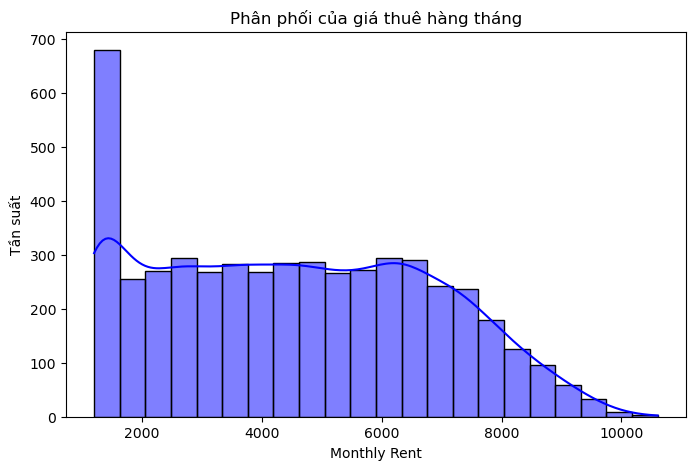

In [11]:
# 2. Phân phối của monthly_rent
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
sns.histplot(df['monthly_rent'], kde=True, color='blue')
plt.title('Phân phối của giá thuê hàng tháng')
plt.xlabel('Monthly Rent')
plt.ylabel('Tần suất')
plt.show()

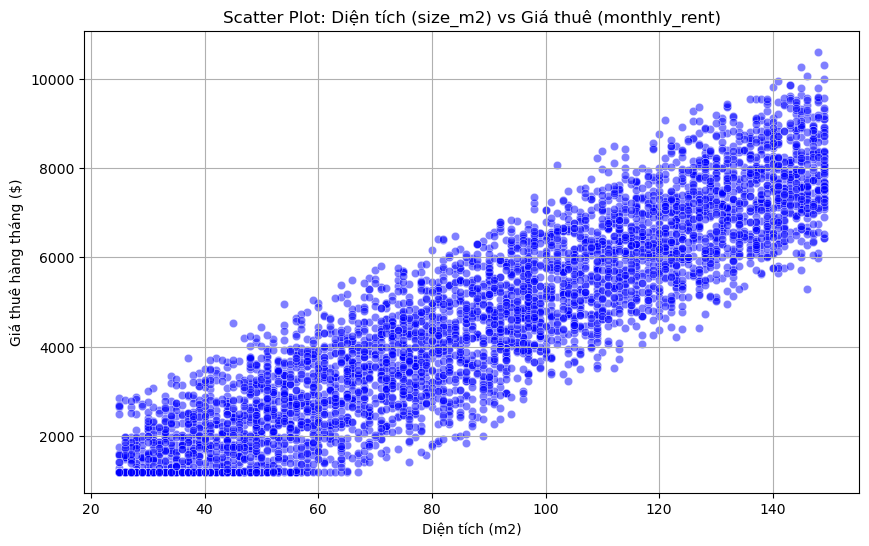

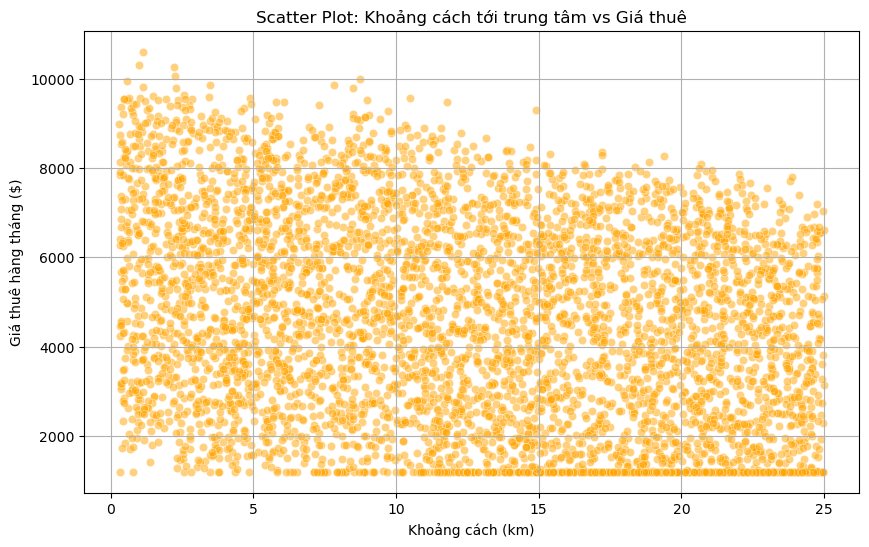

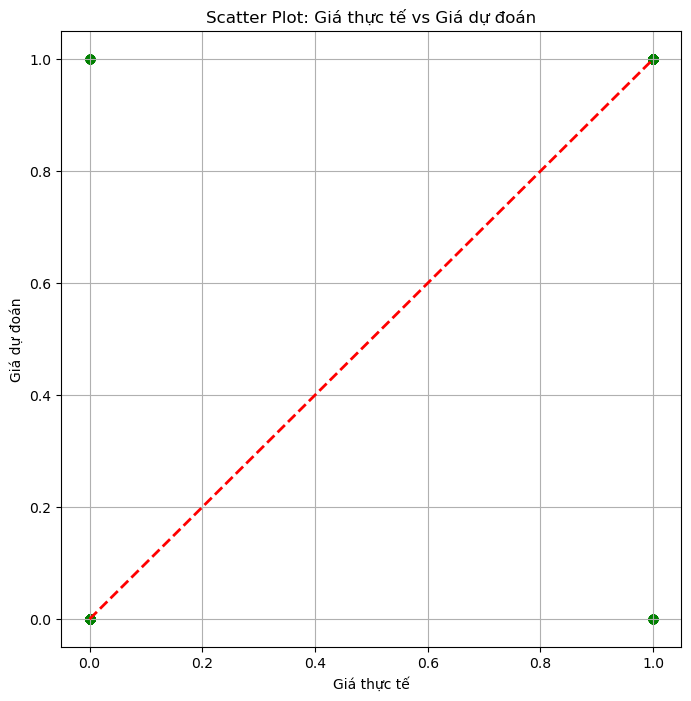

In [12]:

# 1. Vẽ mối quan hệ giữa Diện tích và Giá thuê
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='size_m2', y='monthly_rent', alpha=0.5, color='blue')
plt.title('Scatter Plot: Diện tích (size_m2) vs Giá thuê (monthly_rent)')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá thuê hàng tháng ($)')
plt.grid(True)
plt.show()

# 2. Vẽ mối quan hệ giữa Khoảng cách và Giá thuê
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance_center', y='monthly_rent', alpha=0.5, color='orange')
plt.title('Scatter Plot: Khoảng cách tới trung tâm vs Giá thuê')
plt.xlabel('Khoảng cách (km)')
plt.ylabel('Giá thuê hàng tháng ($)')
plt.grid(True)
plt.show()

# 3. Vẽ So sánh Giá thực tế và Dự đoán (Dùng kết quả từ Câu 2 & 4)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Scatter Plot: Giá thực tế vs Giá dự đoán')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.grid(True)
plt.show()